In [80]:
###Load packages###
import pandas as pd
import os
import ast
from scipy import stats
from matplotlib import pyplot as plt
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind
import numpy as np
import statsmodels.formula.api as smf


###Load cleaned dataset###

#Set file paths
topdir = '/Users/sm6511/Desktop/Prediction-Accomodation-Exp'
study = 'Study2.0'
cleandir = os.path.join(topdir, f'data/{study}/Cleaned')
outputdir = os.path.join(topdir, f'Analysis/{study}')
outputdirCombined = os.path.join(topdir, f'data/Combined')
os.makedirs(outputdir, exist_ok=True)

#Read in cleaned data 
accomodate_path = os.path.join(cleandir, f'{study}Accommodate.csv')
predict_path   = os.path.join(cleandir, f'{study}Predict.csv')

df_accommodate = pd.read_csv(accomodate_path)
df_predict   = pd.read_csv(predict_path)

df_accommodate['task'] = 'accommodate'
df_predict['task']   = 'predict'


print("Accommodate columns:", df_accommodate.columns.tolist())
print("Predict columns:", df_predict.columns.tolist())


Accommodate columns: ['participant', 'free_texts', 'feedback', 'food_amount', 'trial_stop_time', 'testing_image_order', 'testing_responses', 'training_categories', 'training_tail', 'training_wing', 'training_color', 'testing_categories', 'conditionOrder', 'training_image_order', 'attention_check', 'relevant_dim_1', 'relevant_dim_2', 'irrelevant_dim', 'color_high', 'color_low', 'wing_high', 'wing_low', 'tail_high', 'tail_low', 'wing_discrete_slider.response', 'wing_direction_slider.response', 'wing_continuous_slider.response', 'color_discrete_slider.response', 'color_direction_slider.response', 'color_continuous_slider.response', 'tail_discrete_slider.response', 'tail_direction_slider.response', 'tail_continuous_slider.response', 'task']
Predict columns: ['participant', 'training_responses', 'food_amount', 'error', 'feedback', 'trial_stop_time', 'testing_image_order', 'testing_responses', 'training_categories', 'training_tail', 'training_wing', 'training_color', 'testing_categories', 'c

In [81]:
#Converting string representations of lists back to lists

def parse_list_column(x):
    """take column entries that are strings representing lists and convert them to actual lists"""
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        x = x.strip()
        if x.startswith('[') and x.endswith(']'):
            return ast.literal_eval(x)
        else:
            return [x]
    return []
for col in ['training_tail', 'training_wing', 'training_color', 'training_image_order', 'training_categories', 'testing_categories']:
    df_accommodate[col] = df_accommodate[col].apply(parse_list_column)
    df_predict[col]   = df_predict[col].apply(parse_list_column)

df_accommodate['testing_responses'] = df_accommodate['testing_responses'].apply(ast.literal_eval)
df_accommodate['food_amount'] = df_accommodate['food_amount'].apply(ast.literal_eval)
df_accommodate['testing_image_order'] = df_accommodate['testing_image_order'].apply(ast.literal_eval)
df_predict['testing_responses'] = df_predict['testing_responses'].apply(ast.literal_eval)
df_predict['food_amount'] = df_predict['food_amount'].apply(ast.literal_eval)
df_predict['testing_image_order'] = df_predict['testing_image_order'].apply(ast.literal_eval)
#Combine the dataframes and create an arbitrary column for participant numbering (the yoked orders are already stored in 'conditionOrder')
df_combined = pd.concat([df_accommodate, df_predict], ignore_index=True)
df_combined['participant'] = range(1, len(df_combined) + 1)



In [82]:
# Load explanation coding
coding_path = os.path.join(
    topdir,
    "data/Combined/explanationcodes/Explanation_Coding_Study2.csv"
)

df_coding = pd.read_csv(coding_path)

# Drop empty rows 
df_coding = df_coding.dropna(subset=["participant"]).copy()

# Convert participant IDs (unique condition order identifiers)
df_coding["participant"] = df_coding["participant"].astype(int)
df_accommodate["participant"] = df_accommodate["participant"].astype(int)

# Treat blank cells as 0, coded cells as 1
coding_cols = ["None", "Causal_Explanation", 
               "Color", "Tail", "Wing", 'All']

for col in coding_cols:
    df_coding[col] = df_coding[col].fillna(0)
    df_coding[col] = df_coding[col].replace("", 0)
    df_coding[col] = df_coding[col].astype(int)


# Category Mapping:
# None / Explanation / Causal_Explanation only -> none
# Color -> Color
# Tail -> Tail
# stripes+Tail -> both

# Broad causal flag: marked causal OR feature-specific causal
df_coding["causal_color"] = (
    df_coding["Color"].eq(1)
    | df_coding["All"].eq(1)
)

df_coding["causal_tail"] = (
    df_coding["Tail"].eq(1)
    | df_coding["All"].eq(1)
)

df_coding["causal_wing"] = (
    df_coding["Wing"].eq(1)
    | df_coding["All"].eq(1)
)

# Broad causal flag
df_coding["has_causal_explanation"] = (
    df_coding["Causal_Explanation"].eq(1)
    | df_coding["causal_color"]
    | df_coding["causal_tail"]
    | df_coding["causal_wing"]
)

df_accommodate = df_accommodate.merge(
    df_coding[
        [
            "participant",
            "has_causal_explanation",
            "causal_color",
            "causal_tail",
            "causal_wing",
        ]
    ],
    on="participant",
    how="left"
)

# Participants not in coding file default to none
df_accommodate["has_causal_explanation"] = df_accommodate["has_causal_explanation"].fillna(False)
df_accommodate["causal_color"] = df_accommodate["causal_color"].fillna(False)
df_accommodate["causal_tail"] = df_accommodate["causal_tail"].fillna(False)
df_accommodate["causal_wing"] = df_accommodate["causal_wing"].fillna(False)

In [83]:
df_combined = pd.concat([df_accommodate, df_predict], ignore_index=True)

In [85]:
participant_id = 216

row = df_accommodate.loc[
    df_accommodate["participant"] == participant_id
].iloc[0]

print(f"Participant: {participant_id}")
#print(f"Explanation type: {row['explanation_type']}")
print(f"Has causal explanation: {row['has_causal_explanation']}")
print(f"Causal tail: {row['causal_tail']}")
print(f"Causal color: {row['causal_color']}")
print(f"Causal wing: {row['causal_wing']}")
print("\n--- FREE TEXTS ---\n")

import ast

free_texts = row["free_texts"]

if isinstance(free_texts, str):
    free_texts = ast.literal_eval(free_texts)

for text in free_texts:
    print(text)
    print()

Participant: 216
Has causal explanation: False
Causal tail: False
Causal color: False
Causal wing: False

--- FREE TEXTS ---

It is small and did not go so far to find food

It did twice the distance than the yellow and it is blue

It has wings and paws

it has a long tail

That makes sense, same sperk ate the same amount of chili pepper

It has a long tail

It has paws and wings and a long tail

It has a curvy tail

It has a long tail

it has a curvy tail

it has a curvy tail

it has wings and wings and a long tail

it has a long tail

it has a curvy tail

It has a long tail and it is blue

it has curvy tail, wings  and it is blue

It has curvy tail, wings and paws, it is blue

it has curvy tail

it has long tail, wings and pwas

It has long tail and it should have walked a long distance to got its food

it has a long tail, and walked a long distance

it has curvy tail

it has a long tail

it has a curvy tail



In [48]:
df_combined = pd.concat([df_accommodate, df_predict], ignore_index=True)
print(df_combined)

     participant                                         free_texts  \
0            216  ['It is small and did not go so far to find fo...   
1             31  ["with front paws, it's less efficient to trav...   
2            142  ["Hard to say as it's the first sperk I've see...   
3             18  ['They have wings', 'they have a tail', 'they ...   
4             62  ['It has paws, is yellow and has a straight ta...   
..           ...                                                ...   
413          183                                                NaN   
414          178                                                NaN   
415          172                                                NaN   
416            4                                                NaN   
417           18                                                NaN   

                   feedback  \
0                        []   
1                        []   
2                        []   
3                      

In [49]:
import pandas as pd
from scipy.stats import chi2_contingency

# Loop through rows and determine model parameter score for each participant
participant_rows = []

for _, row in df_combined.iterrows():
    wing_yes  = 1 if row['wing_discrete_slider.response'] == 'Yes' else 0
    color_yes = 1 if row['color_discrete_slider.response'] == 'Yes' else 0
    tail_yes  = 1 if row['tail_discrete_slider.response'] == 'Yes' else 0

    model_param_score = wing_yes + color_yes + tail_yes

    participant_rows.append({
        'participant': row['participant'],
        'task': row['task'],  # predict vs accommodate,
        'model_param_score': model_param_score,
        'conditionOrder': row['conditionOrder'],
        'explanation_type': row['explanation_type'],
        'irrelevant_dim': row['irrelevant_dim'],
        'relevant_dim_1': row['relevant_dim_1'],
        'relevant_dim_2': row['relevant_dim_2'] if 'relevant_dim_2' in row else None,
        'wing_high': row['wing_high'],
        'overfit': model_param_score == 2  # overfit if both dimensions selected
    })

df_params = pd.DataFrame(participant_rows)

# Compare overfit vs not by condition
contingency = pd.crosstab(
    df_params['task'],
    df_params['overfit']
)

print(contingency)

chi2, p, dof, expected = chi2_contingency(contingency)

print(f"Chi-square = {chi2:.3f}")
print(f"df = {dof}")
print(f"p-value = {p:.4f}")

overfit_summary = (
    df_params
    .groupby('task')['overfit']
    .mean()
    .reset_index()
)

overfit_summary['overfit_percent'] = overfit_summary['overfit'] * 100

# Plot
fig, ax = plt.subplots(figsize=(6, 5))

bars = ax.bar(
    overfit_summary['task'],
    overfit_summary['overfit_percent'],
    width=0.5
)

# Labels
ax.set_ylabel('Overfitting (%)')
ax.set_xlabel('Task')
ax.set_title('Overfitting Rate by Task')

# Clean look (matches your usual style)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f'{height:.1f}%',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

KeyError: 'explanation_type'

  explanation_type    n  overfit_n  overfit_rate  overfit_percent
0             none  172         70      0.406977        40.697674
1             wing   19          5      0.263158        26.315789
2            color    3          1      0.333333        33.333333
3             tail    8          2      0.250000        25.000000
4             both    7          2      0.285714        28.571429


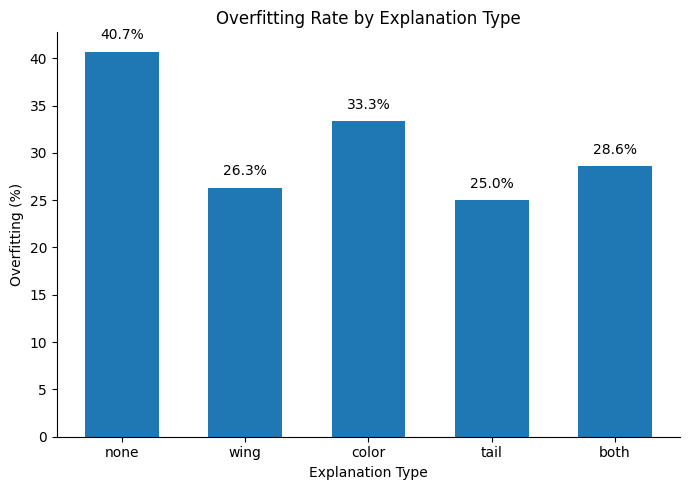

In [32]:
import matplotlib.pyplot as plt

# Participant-level overfit by new coding format
participant_level = df_params.drop_duplicates(subset=["participant", "task"]).copy()

# Use new explanation_type column
order = ["none", "wing", "color", "tail", "both"]

participant_level["explanation_type"] = pd.Categorical(
    participant_level["explanation_type"],
    categories=order,
    ordered=True
)

# Print counts + overfit rates
overfit_by_explanation = (
    participant_level
    .groupby("explanation_type", observed=False)
    .agg(
        n=("participant", "nunique"),
        overfit_n=("overfit", "sum"),
        overfit_rate=("overfit", "mean")
    )
    .reset_index()
)

overfit_by_explanation["overfit_percent"] = (
    overfit_by_explanation["overfit_rate"] * 100
)

print(overfit_by_explanation)

# Plot
fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    overfit_by_explanation["explanation_type"].astype(str),
    overfit_by_explanation["overfit_percent"],
    width=0.6
)

ax.set_ylabel("Overfitting (%)")
ax.set_xlabel("Explanation Type")
ax.set_title("Overfitting Rate by Explanation Type")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{height:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

           task explanation_type irrelevant_dim      mean  sum  count  \
0   accommodate             none          color  0.428571   18     42   
1   accommodate             none           tail  0.488889   22     45   
2   accommodate             none           wing  0.352941   30     85   
3   accommodate             wing          color  0.500000    2      4   
4   accommodate             wing           tail  0.000000    0      4   
5   accommodate             wing           wing  0.272727    3     11   
6   accommodate            color          color       NaN    0      0   
7   accommodate            color           tail  1.000000    1      1   
8   accommodate            color           wing  0.000000    0      2   
9   accommodate             tail          color  0.000000    0      4   
10  accommodate             tail           tail  0.000000    0      1   
11  accommodate             tail           wing  0.666667    2      3   
12  accommodate             both          color  1.

/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_40061/983248298.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['task', 'explanation_type', 'irrelevant_dim'])['overfit']


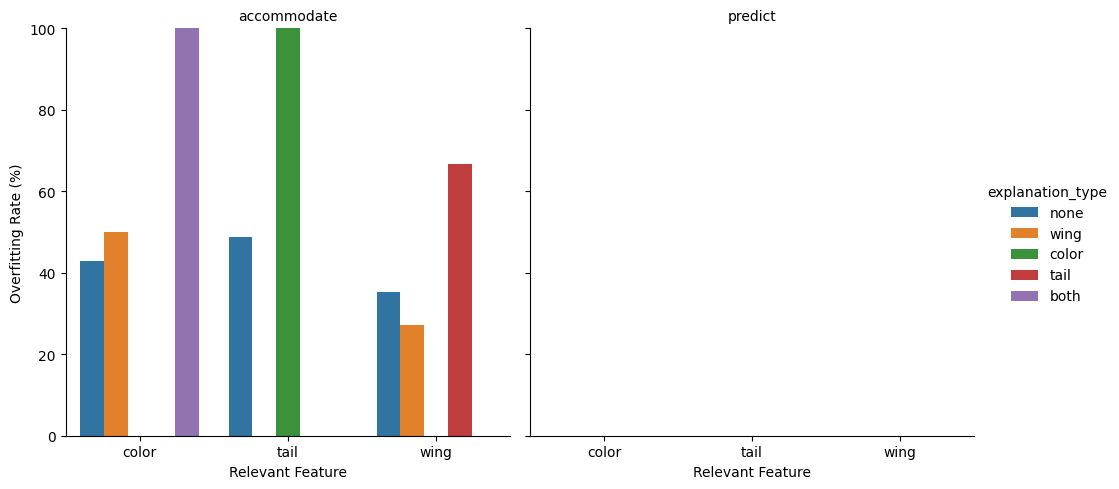

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

# Summarize from participant-level data
overfit_summary = (
    participant_level
    .groupby(['task', 'explanation_type', 'irrelevant_dim'])['overfit']
    .agg(['mean', 'sum', 'count'])
    .reset_index()
)

overfit_summary['overfit_percent'] = overfit_summary['mean'] * 100

print(overfit_summary)

# Plot
g = sns.catplot(
    data=overfit_summary,
    x='irrelevant_dim',
    y='overfit_percent',
    hue='explanation_type',
    col='task',
    kind='bar',
    height=5,
    aspect=1
)

g.set_axis_labels('Relevant Feature', 'Overfitting Rate (%)')
g.set_titles('{col_name}')
g.set(ylim=(0, 100))

for ax in g.axes.flat:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.show()

In [86]:
# Create map from feature response labels to internal short codes

wing_map = {
    "wings": "t",
    "paws": "n",
}

color_map = {
    "blue": "b",
    "yellow": "y",
}

tail_map = {
    "curly": "c",
    "straight": "s",
}

feature_maps = {
    "wing": wing_map,
    "color": color_map,
    "tail": tail_map,
}


# Compute feature importance scores

def compute_feature_importance_from_df(df):
    """
    Compute numeric feature-importance scores from -7 to 7.

    A score of 0 indicates that the participant said the feature was not
    relevant, did not respond, or selected a direction that could not be
    matched to the stored high/low feature values.
    """

    df = df.copy()
    features = ["wing", "color", "tail"]

    def normalize_str(value):
        """Strip whitespace, collapse repeated spaces, and lowercase strings."""
        if isinstance(value, str):
            return " ".join(value.split()).lower()
        return ""

    def compute_row_importance(row, feat):
        disc = row[f"{feat}_discrete_slider.response"]
        direction = row[f"{feat}_direction_slider.response"]
        continuous = row[f"{feat}_continuous_slider.response"]

        # If the participant said the feature was not relevant,
        # or did not answer, importance is zero
        if disc == "No" or pd.isna(disc):
            return 0.0

        # Missing continuous response defaults to zero
        cont_val = float(continuous) if not pd.isna(continuous) else 0.0

        mapping = feature_maps.get(feat, {})

        direction_norm = normalize_str(direction)
        internal_direction = mapping.get(direction_norm)

        high_val = normalize_str(row[f"{feat}_high"])
        low_val = normalize_str(row[f"{feat}_low"])

        # Positive if the selected direction matches the true high value
        if internal_direction == high_val:
            sign = 1

        # Negative if the selected direction matches the true low value
        elif internal_direction == low_val:
            sign = -1

        # Unmatched or missing response
        else:
            sign = 0
            cont_val = 0.0

        return cont_val * sign

    for feat in features:
        df[f"{feat}_importance"] = df.apply(
            lambda row: compute_row_importance(row, feat),
            axis=1,
        )

    return df


df_combined = compute_feature_importance_from_df(df_combined)


# Create participant-level explanation group:
# predict
# accommodate_causal
# accommodate_none

df_combined["task_explanation_group"] = np.select(
    [
        df_combined["task"].eq("predict"),
        (
            df_combined["task"].eq("accommodate")
            & df_combined["has_causal_explanation"].fillna(False)
        ),
        (
            df_combined["task"].eq("accommodate")
            & ~df_combined["has_causal_explanation"].fillna(False)
        ),
    ],
    [
        "predict",
        "accommodate_causal",
        "accommodate_none",
    ],
    default=pd.NA,
)


# Reshape to long format:
# one row per participant × feature dimension

cols_to_keep = [
    "participant",
    "task",
    "task_explanation_group",
    "tail_importance",
    "color_importance",
    "wing_importance",
    "has_causal_explanation",
    "causal_tail",
    "causal_color",
    "causal_wing",
    "relevant_dim_1",
    "relevant_dim_2",
    "irrelevant_dim",
    "color_high",
    "wing_high",
    "tail_discrete_slider.response",
    "wing_discrete_slider.response",
]

df_long = df_combined[cols_to_keep].copy()

df_long = df_long.melt(
    id_vars=[
        "participant",
        "task",
        "task_explanation_group",
        "has_causal_explanation",
        "causal_tail",
        "causal_color",
        "causal_wing",
        "relevant_dim_1",
        "relevant_dim_2",
        "irrelevant_dim",
        "color_high",
        "wing_high",
        "tail_discrete_slider.response",
        "wing_discrete_slider.response",
    ],
    value_vars=[
        "tail_importance",
        "color_importance",
        "wing_importance",
    ],
    var_name="feature_dimension",
    value_name="feature_importance",
)

# Simplify feature-dimension names
df_long["feature_dimension"] = (
    df_long["feature_dimension"]
    .str.replace("_importance", "", regex=False)
)


# Create row-level indicator:
# Did this participant provide a causal explanation for this specific feature?

df_long["had_causal_explanation_for_feature"] = np.select(
    [
        df_long["feature_dimension"].eq("tail"),
        df_long["feature_dimension"].eq("color"),
        df_long["feature_dimension"].eq("wing"),
    ],
    [
        df_long["causal_tail"].fillna(False),
        df_long["causal_color"].fillna(False),
        df_long["causal_wing"].fillna(False),
    ],
    default=False,
).astype(bool)

# Predictors should always be False
df_long["had_causal_explanation_for_feature"] = (
    df_long["had_causal_explanation_for_feature"]
    & df_long["task"].eq("accommodate")
)


# Create the feature-specific three-level grouping used for plotting:
# predictor
# explainer
# non_explainer

df_long["feature_explanation_group"] = np.select(
    [
        df_long["task"].eq("predict"),
        (
            df_long["task"].eq("accommodate")
            & df_long["had_causal_explanation_for_feature"]
        ),
        (
            df_long["task"].eq("accommodate")
            & ~df_long["had_causal_explanation_for_feature"]
        ),
    ],
    [
        "predictor",
        "explainer",
        "non_explainer",
    ],
    default=pd.NA,
)


# Determine whether each feature was relevant or irrelevant

df_long["feature_relevance"] = np.where(
    df_long.apply(
        lambda row: row["feature_dimension"]
        in [row["relevant_dim_1"], row["relevant_dim_2"]],
        axis=1,
    ),
    "relevant",
    "irrelevant",
)


# Optional checks


/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_58135/1686959199.py:103: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  & df_combined["has_causal_explanation"].fillna(False)
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_58135/1686959199.py:107: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  & ~df_combined["has_causal_explanation"].fillna(False)
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_58135/1686959199.py:187: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in 

In [87]:
print(df_long.tail())

      participant     task task_explanation_group has_causal_explanation  \
1249          183  predict                predict                    NaN   
1250          178  predict                predict                    NaN   
1251          172  predict                predict                    NaN   
1252            4  predict                predict                    NaN   
1253           18  predict                predict                    NaN   

     causal_tail causal_color causal_wing relevant_dim_1 relevant_dim_2  \
1249         NaN          NaN         NaN          color           wing   
1250         NaN          NaN         NaN           tail          color   
1251         NaN          NaN         NaN          color           tail   
1252         NaN          NaN         NaN          color           tail   
1253         NaN          NaN         NaN          color           tail   

     irrelevant_dim color_high wing_high tail_discrete_slider.response  \
1249           tai

In [88]:
print(
    df_long.groupby(
        ["feature_dimension", "feature_explanation_group"],
        dropna=False,
    ).size()
)

print(
    df_long.loc[
        df_long["participant"].eq(31),
        [
            "participant",
            "task",
            "feature_dimension",
            "causal_color",
            "causal_tail",
            "causal_wing",
            "had_causal_explanation_for_feature",
            "feature_explanation_group",
            "feature_importance",
            "feature_relevance",
        ],
    ].sort_values("feature_dimension")
)

feature_dimension  feature_explanation_group
color              explainer                      8
                   non_explainer                201
                   predictor                    209
tail               explainer                     13
                   non_explainer                196
                   predictor                    209
wing               explainer                     32
                   non_explainer                177
                   predictor                    209
dtype: int64
      participant         task feature_dimension causal_color causal_tail  \
419            31  accommodate             color         True       False   
798            31      predict             color          NaN         NaN   
1              31  accommodate              tail         True       False   
380            31      predict              tail          NaN         NaN   
837            31  accommodate              wing         True       False   
1216        

In [89]:
df_long.groupby(
    ["task",  "had_causal_explanation_for_feature"],
    dropna=False
).size()

task         had_causal_explanation_for_feature
accommodate  False                                 574
             True                                   53
predict      False                                 627
dtype: int64

In [90]:
participant_summary = (
    df_long[["participant", "task", "has_causal_explanation"]]
    .drop_duplicates()
)

participant_summary["has_causal_explanation"].value_counts()

has_causal_explanation
False    172
True      37
Name: count, dtype: int64

In [91]:
df_long.groupby(
    ["task", "feature_dimension", "had_causal_explanation_for_feature"],
    dropna=False
).size()

task         feature_dimension  had_causal_explanation_for_feature
accommodate  color              False                                 201
                                True                                    8
             tail               False                                 196
                                True                                   13
             wing               False                                 177
                                True                                   32
predict      color              False                                 209
             tail               False                                 209
             wing               False                                 209
dtype: int64

In [92]:
df_long.to_csv(os.path.join(outputdirCombined, 'df_long_by_explanation_for_R-Study2.csv'), index=False)

In [10]:
df_wing = df_long[df_long["feature_dimension"] == "wing"].copy()
df_wing["wing_relevant"] = (df_wing["feature_relevance"] == "relevant").astype(int) #Code relevancy as 0/1
df_wing["wing_high"] = (df_wing["wing_high"] == "T").astype(int) #Code having a wing as 0/1
print(df_wing)
df_wing.to_csv(os.path.join(outputdirCombined, 'df_wing_byexplanation_for_R-Study2.csv'), index=False)

      participant         task task_explanation_group explanation_type  \
836           216  accommodate     accommodate_causal             both   
837            31  accommodate     accommodate_causal            color   
838           142  accommodate     accommodate_causal             wing   
839            18  accommodate       accommodate_none             none   
840            62  accommodate       accommodate_none             none   
...           ...          ...                    ...              ...   
1249          183      predict                predict              NaN   
1250          178      predict                predict              NaN   
1251          172      predict                predict              NaN   
1252            4      predict                predict              NaN   
1253           18      predict                predict              NaN   

     has_causal_explanation relevant_dim_1 relevant_dim_2 irrelevant_dim  \
836                    True        

/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_40061/2141393795.py:22: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_40061/2141393795.py:33: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.pointplot(
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_40061/2141393795.py:33: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


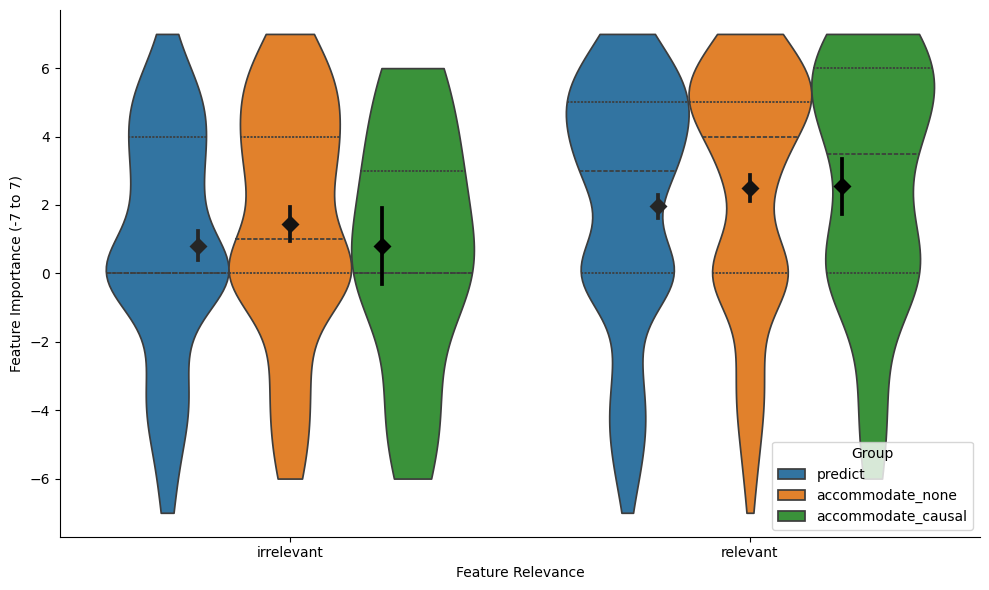

In [39]:
df_long["feature_dimension"] = df_long["feature_dimension"].str.replace("_importance", "")

df_long["feature_relevance"] = df_long.apply(
    lambda row: "relevant" if row["feature_dimension"] == row["relevant_dim_1"] or row["feature_dimension"] == row["relevant_dim_2"] else "irrelevant",
    axis=1
)

df_long["feature_relevance"] = pd.Categorical(
    df_long["feature_relevance"],
    categories=["irrelevant", "relevant"],
    ordered=True
)

df_long["task_explanation_group"] = pd.Categorical(
    df_long["task_explanation_group"],
    categories=["predict", "accommodate_none", "accommodate_causal"],
    ordered=True
)

plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df_long,
    x="feature_relevance",
    y="feature_importance",
    hue="task_explanation_group",
    inner="quartile",
    cut=0,
    scale="width"
)

# Overlay means + 95% CI
sns.pointplot(
    data=df_long,
    x="feature_relevance",
    y="feature_importance",
    hue="task_explanation_group",
    dodge=0.4,
    join=False,
    markers="D",
    errorbar=("ci", 95),
    color="black",
    legend=False
)

sns.despine()
plt.ylabel("Feature Importance (-7 to 7)")
plt.xlabel("Feature Relevance")

# Remove duplicate legend entries
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:3], labels[:3], title="Group", loc="lower right")

plt.tight_layout()
plt.show()

/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_40061/1280489144.py:22: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_40061/1280489144.py:33: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.pointplot(
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_40061/1280489144.py:33: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


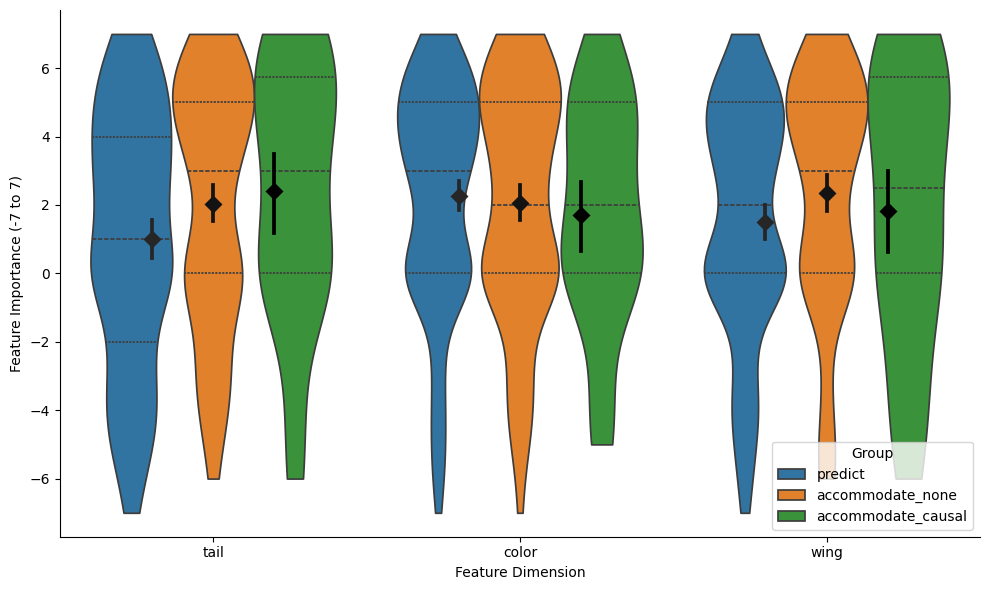

In [41]:
df_long["feature_dimension"] = df_long["feature_dimension"].str.replace("_importance", "")

df_long["feature_relevance"] = df_long.apply(
    lambda row: "relevant" if row["feature_dimension"] == row["relevant_dim_1"] or row["feature_dimension"] == row["relevant_dim_2"] else "irrelevant",
    axis=1
)

df_long["feature_relevance"] = pd.Categorical(
    df_long["feature_relevance"],
    categories=["irrelevant", "relevant"],
    ordered=True
)

df_long["task_explanation_group"] = pd.Categorical(
    df_long["task_explanation_group"],
    categories=["predict", "accommodate_none", "accommodate_causal"],
    ordered=True
)

plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df_long,
    x="feature_dimension",
    y="feature_importance",
    hue="task_explanation_group",
    inner="quartile",
    cut=0,
    scale="width"
)

# Overlay means + 95% CI
sns.pointplot(
    data=df_long,
    x="feature_dimension",
    y="feature_importance",
    hue="task_explanation_group",
    dodge=0.4,
    join=False,
    markers="D",
    errorbar=("ci", 95),
    color="black",
    legend=False
)

sns.despine()
plt.ylabel("Feature Importance (-7 to 7)")
plt.xlabel("Feature Dimension")

# Remove duplicate legend entries
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:3], labels[:3], title="Group", loc="lower right")

plt.tight_layout()
plt.show()

/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_10790/2143848677.py:23: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


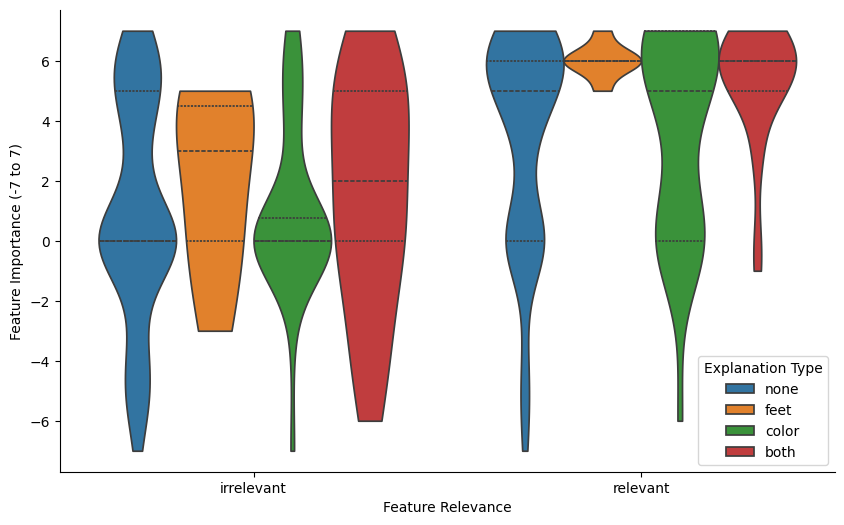

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Keep only accommodate participants
df_long_acc = df_long[df_long['task'] == 'accommodate'].copy()

# Order categories
df_long_acc['feature_relevance'] = pd.Categorical(
    df_long_acc['feature_relevance'],
    categories=['irrelevant', 'relevant'],
    ordered=False
)

df_long_acc['explanation_type'] = pd.Categorical(
    df_long_acc['explanation_type'],
    categories=['none', 'feet', 'color', 'both'],
    ordered=False
)

plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df_long_acc,
    x='feature_relevance',
    y='feature_importance',
    hue='explanation_type',
    inner='quartile',
    cut=0,
    scale='width'
)

sns.despine()
plt.ylabel('Feature Importance (-7 to 7)')
plt.xlabel('Feature Relevance')
plt.legend(title='Explanation Type', loc='lower right')
plt.show()

/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_10790/1302865567.py:23: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


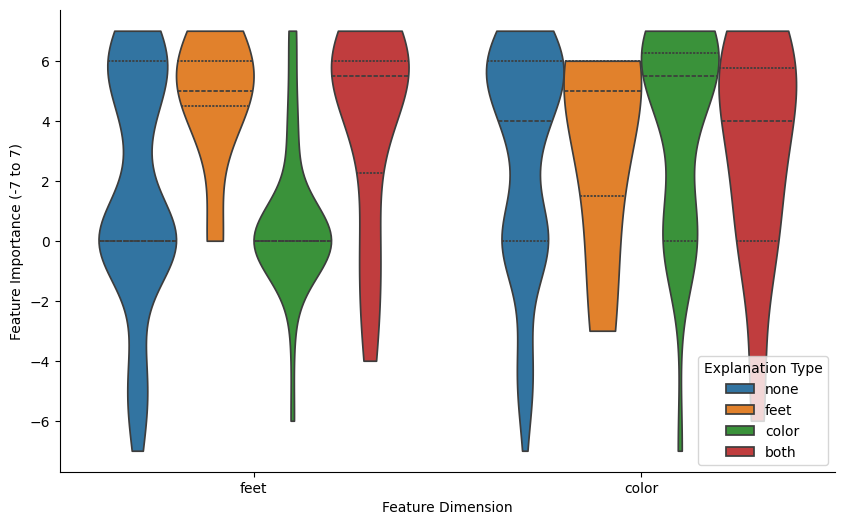

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Keep only accommodate participants
df_long_acc = df_long[df_long['task'] == 'accommodate'].copy()

# Order categories
df_long_acc['feature_dimension'] = pd.Categorical(
    df_long_acc['feature_dimension'],
    categories=['feet', 'color'],
    ordered=False
)

df_long_acc['explanation_type'] = pd.Categorical(
    df_long_acc['explanation_type'],
    categories=['none', 'feet', 'color', 'both'],
    ordered=False
)

plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df_long_acc,
    x='feature_dimension',
    y='feature_importance',
    hue='explanation_type',
    inner='quartile',
    cut=0,
    scale='width'
)

sns.despine()
plt.ylabel('Feature Importance (-7 to 7)')
plt.xlabel('Feature Dimension')
plt.legend(title='Explanation Type', loc='lower right')
plt.show()

In [22]:
print(df_long_acc)

     participant         task task_explanation_group explanation_type  \
0            226  accommodate       accommodate_none             none   
1            210  accommodate       accommodate_none             none   
2            269  accommodate     accommodate_causal             both   
3            215  accommodate       accommodate_none             none   
4             83  accommodate       accommodate_none             none   
..           ...          ...                    ...              ...   
874          144  accommodate       accommodate_none             none   
875            8  accommodate       accommodate_none             none   
876          167  accommodate       accommodate_none             none   
877           28  accommodate       accommodate_none             none   
878          154  accommodate       accommodate_none             none   

     has_causal_explanation relevant_dim irrelevant_dim stripes_high  \
0                     False      stripes           

In [25]:
print(df_combined)

     participant                                         free_texts  \
0            226  [This reptile presents with stripes that move ...   
1            210  [It has produced many offsprings, Few offsprin...   
2            269  [The webbed toes are not efficient for a tree ...   
3            215  [Presumably this reptile received a high ferti...   
4             83  [The reptile may have low viability of hatchli...   
..           ...                                                ...   
581          235                                                NaN   
582           78                                                NaN   
583          197                                                NaN   
584          265                                                NaN   
585           86                                                NaN   

                                              feedback  \
0    ['There did not appear to be sufficient inform...   
1                              

In [35]:
#Group by average food amount per item in training
df = df_combined[['task', 'explanation_type',  'training_image_order', 'fertility_score', 'conditionOrder']]
df_long2 = (
    df
    .explode(['training_image_order', 'fertility_score'])
    .rename(columns={'training_image_order': 'item'})
)
avg_food = (
    df_long2
    .groupby(['task', 'explanation_type', 'conditionOrder', 'item'], as_index=False)
    ['fertility_score']
    .mean()
)
avg_food_train = avg_food.copy()
print(avg_food_train.tail(200))
#Get food consumption ratings by item

df = df_combined[['task', 'explanation_type', 'conditionOrder', 'testing_image_order', 'testing_responses',
                  'relevant_dim', 'irrelevant_dim', 'stripes_high', 'feet_high']]
df_long2 = (
    df
    .explode(['testing_image_order', 'testing_responses'])
    .rename(columns={'testing_image_order': 'item'})
)
avg_food_test = df_long2.copy()
print(avg_food_test)

#Now merge the two (actual food amounts in training vs ratings in testing) and compute error
df_merged = avg_food_test.merge(
    avg_food_train,
    on=['task', 'explanation_type', 'conditionOrder', 'item'],
    how='left'
)

#Add Error and absolute error
df_merged['error'] = (
    df_merged['testing_responses'] - df_merged['fertility_score']
)
df_merged['abs_error'] = df_merged['error'].abs()
df_merged[['stripes', 'feet']] = df_merged['item'].str.split('_', expand=True)

print(df_merged)

             task explanation_type  conditionOrder item fertility_score
972   accommodate             none             246  E_C            3.25
973   accommodate             none             246  E_F             2.5
974   accommodate             none             246  W_C            8.75
975   accommodate             none             246  W_F             6.0
976   accommodate             none             247  E_C            4.25
...           ...              ...             ...  ...             ...
1167  accommodate          stripes             255  W_F             7.5
1168  accommodate          stripes             286  E_C             3.0
1169  accommodate          stripes             286  E_F             4.5
1170  accommodate          stripes             286  W_C             7.5
1171  accommodate          stripes             286  W_F             9.0

[200 rows x 5 columns]
            task explanation_type  conditionOrder item testing_responses  \
0    accommodate             none   

In [37]:
# Columns indicating whether the item's feature is the "high" dimension (1 or 0 coding)
df_merged['stripes_match_high']  = (df_merged['stripes']  == df_merged['stripes_high']).astype(int)
df_merged['feet_match_high'] = (df_merged['feet'] == df_merged['feet_high']).astype(int)
#print(df_merged.head(20))
# Group by participant
participant_corrs = []

for pid, g in df_merged.groupby(['task', 'conditionOrder']):
    for feat in ['stripes','feet']:
        # Column indicating match to high value
        match_col = f"{feat}_match_high"
        
        # Compute correlation
        corr = g['testing_responses'].corr(g[match_col])
        
        # Determine if this feature is relevant for this participant
        relevant = g['relevant_dim'].iloc[0] == feat
        high_col  = f"{feat}_high"
        
        # Store
        participant_corrs.append({
            'participant': pid,
            'task': g['task'].iloc[0],
            'explanation_type': g['explanation_type'].iloc[0],
            'feature_dimension': feat,
            'high_value': g[high_col].iloc[0],
            'feature_relevance': 'relevant' if relevant else 'irrelevant',
            'correlation': corr,
            'irrelevant_dim': g['irrelevant_dim'].iloc[0],
            'abs_correlation': abs(corr) if pd.notna(corr) else None
        })

df_corr = pd.DataFrame(participant_corrs)
print(df_corr.tail(40))



         participant     task explanation_type feature_dimension high_value  \
1132  (predict, 280)  predict              NaN           stripes          E   
1133  (predict, 280)  predict              NaN              feet          F   
1134  (predict, 281)  predict              NaN           stripes          E   
1135  (predict, 281)  predict              NaN              feet          C   
1136  (predict, 282)  predict              NaN           stripes          W   
1137  (predict, 282)  predict              NaN              feet          F   
1138  (predict, 283)  predict              NaN           stripes          W   
1139  (predict, 283)  predict              NaN              feet          F   
1140  (predict, 285)  predict              NaN           stripes          E   
1141  (predict, 285)  predict              NaN              feet          C   
1142  (predict, 286)  predict              NaN           stripes          W   
1143  (predict, 286)  predict              NaN      

/opt/miniconda3/envs/PredictProj/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/miniconda3/envs/PredictProj/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


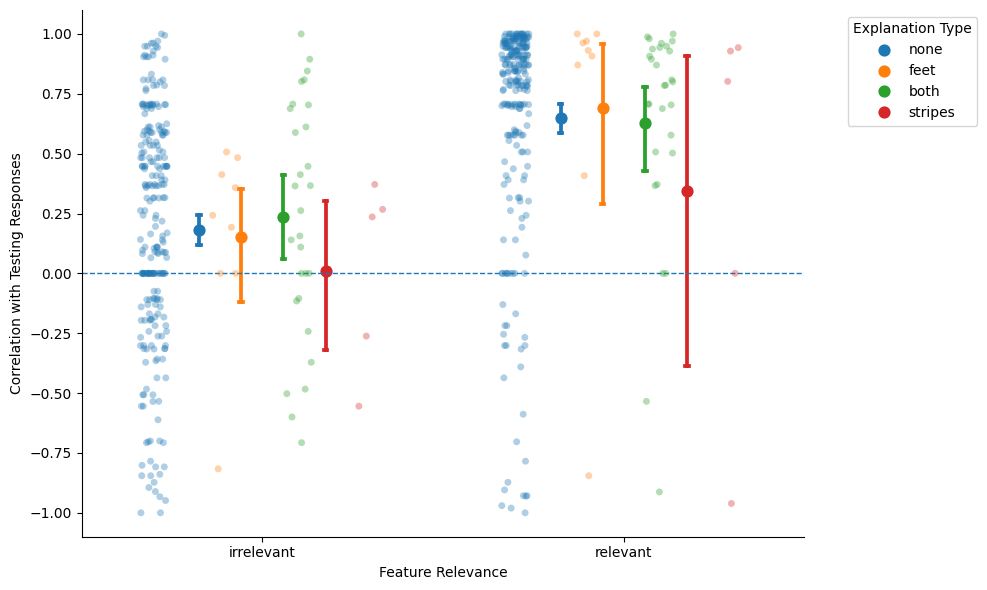

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = df_corr.copy()

plt.figure(figsize=(10, 6))

sns.pointplot(
    data=plot_df,
    x='feature_relevance',
    y='correlation',
    hue='explanation_type',
    errorbar=('ci', 95),
    dodge=0.35,
    markers='o',
    linestyle='none',
    capsize=.01
)

sns.stripplot(
    data=plot_df,
    x='feature_relevance',
    y='correlation',
    hue='explanation_type',
    dodge=True,
    alpha=.35,
    jitter=.15,
    legend=False
)

plt.axhline(0, linestyle='--', linewidth=1)
plt.xlabel("Feature Relevance")
plt.ylabel("Correlation with Testing Responses")
plt.legend(title="Explanation Type", bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine()
plt.tight_layout()
plt.show()

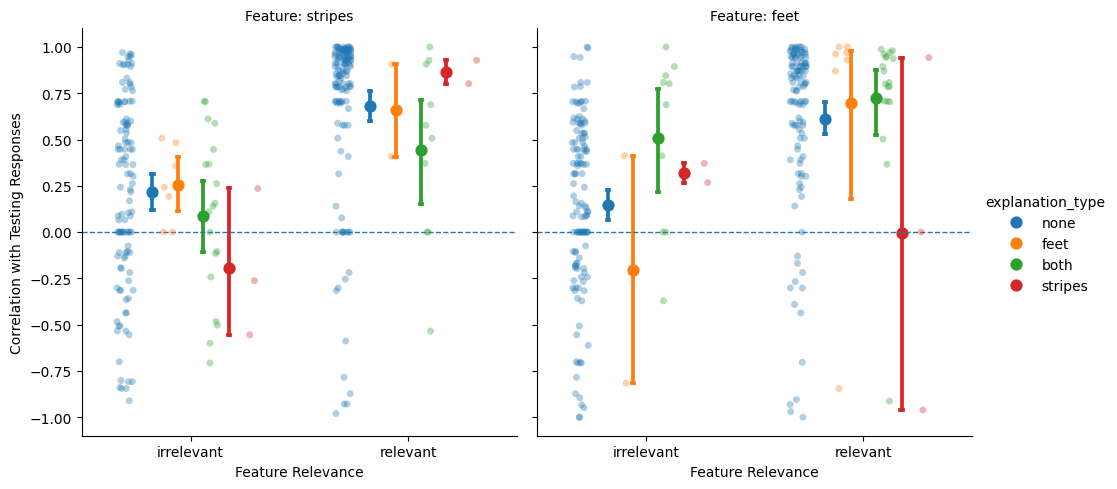

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

g = sns.catplot(
    data=plot_df,
    x='feature_relevance',
    y='correlation',
    hue='explanation_type',
    col='feature_dimension',
    kind='point',
    errorbar=('ci', 95),
    dodge=0.35,
    markers='o',
    linestyle='none',
    capsize=.01,
    height=5,
    aspect=1
)

# Add stripplots to each facet
for ax, feat in zip(g.axes.flat, plot_df['feature_dimension'].unique()):

    sns.stripplot(
        data=plot_df[plot_df['feature_dimension'] == feat],
        x='feature_relevance',
        y='correlation',
        hue='explanation_type',
        dodge=True,
        alpha=.35,
        jitter=.15,
        legend=False,
        ax=ax
    )

    ax.axhline(0, linestyle='--', linewidth=1)

g.set_axis_labels(
    "Feature Relevance",
    "Correlation with Testing Responses"
)

g.set_titles("Feature: {col_name}")

sns.despine()
plt.show()

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Keep only accommodate participants
df_long_acc = df_long[df_long['task'] == 'accommodate'].copy()

# Order categories
df_long_acc['feature_relevance'] = pd.Categorical(
    df_long_acc['feature_relevance'],
    categories=['irrelevant', 'relevant'],
    ordered=False
)

df_long_acc['functional_type'] = pd.Categorical(
    df_long_acc['functional_type'],
    categories=['none', 'feet_only', 'color_only', 'both'],
    ordered=False
)

df_long_acc['relevant_dim'] = pd.Categorical(
    df_long_acc['relevant_dim'],
    categories=['feet', 'color'],
    ordered=False
)

g = sns.catplot(
    data=df_long_acc,
    x='feature_relevance',
    y='feature_importance',
    hue='functional_type',
    col='relevant_dim',
    kind='violin',
    inner='quartile',
    cut=0,
    scale='width',
    height=5,
    aspect=1
)

g.set_axis_labels('Feature Relevance', 'Feature Importance (-7 to 7)')
g.set_titles('Relevant feature: {col_name}')

for ax in g.axes.flat:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.show()

KeyError: 'functional_type'

In [43]:
means = (
    df_long
    .groupby(["task", "feature_relevance"])["feature_importance"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

print(means)


                     task feature_relevance      mean       std  count
0             accommodate        irrelevant  1.073333  3.643688    150
1             accommodate          relevant  3.353333  3.625296    150
2  accommodate_functional        irrelevant  1.194030  3.290200     67
3  accommodate_functional          relevant  4.567164  2.818897     67
4                 predict        irrelevant  1.087558  2.900620    217
5                 predict          relevant  2.935484  3.432616    217


/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_79981/1213789995.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["task", "feature_relevance"])["feature_importance"]


In [47]:
import statsmodels.formula.api as smf
df_long['task'] = pd.Categorical(
    df_long['task'],
    categories=['accommodate', 'accommodate_functional', 'predict']
)

df_long['feature_relevance'] = pd.Categorical(
    df_long['feature_relevance'],
    categories=['irrelevant', 'relevant']
)
# Predicting feature importance from task and feature relevance, with random intercepts for participants
md = smf.mixedlm(
    "feature_importance ~ task * feature_relevance",
    df_long,
    groups=df_long["participant"],  # random intercept per participant
    re_formula="~feature_relevance" # random slopes
)
mdf = md.fit(method='lbfgs')
print(mdf.summary())
#mdf.summary().tables[1].to_csv(os.path.join(outputdir, "mixedlm_featureimportance.csv"))

                                 Mixed Linear Model Regression Results
Model:                         MixedLM              Dependent Variable:              feature_importance
No. Observations:              868                  Method:                          REML              
No. Groups:                    217                  Scale:                           9.0821            
Min. group size:               4                    Log-Likelihood:                  -2265.0976        
Max. group size:               4                    Converged:                       Yes               
Mean group size:               4.0                                                                     
-------------------------------------------------------------------------------------------------------
                                                             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------------------------

/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_79981/341896458.py:11: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


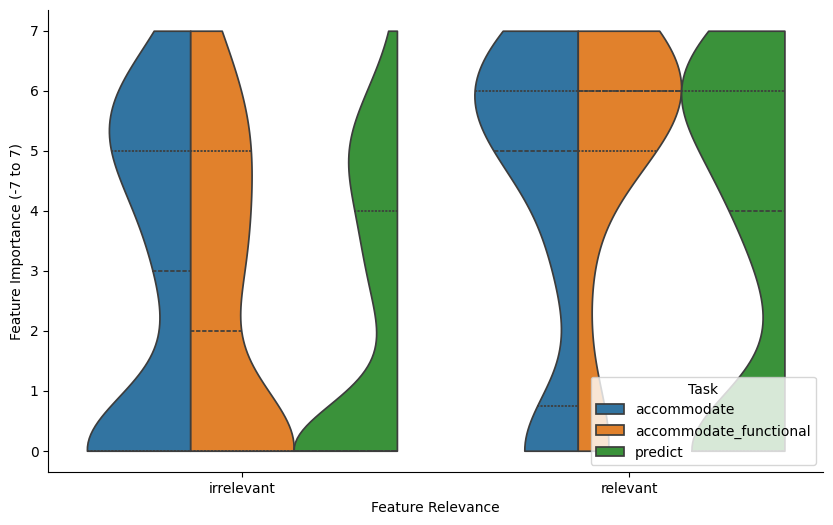

In [46]:
df_longAbs = df_long.copy()
df_longAbs["abs_feature_importance"] = df_longAbs["feature_importance"].abs()


import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))

df_longAbs['feature_relevance'] = pd.Categorical(df_longAbs['feature_relevance'], categories=['irrelevant', 'relevant'], ordered=False)
# Violin plot: distribution of ratings by task and relevance
sns.violinplot(
    data=df_longAbs,
    x='feature_relevance',      # relevant / irrelevant
    y='abs_feature_importance',  # -7 to 7
    hue='task',                 # predict / accomodate
    split=True,                 # split the violins by hue
    inner='quartile',  
    scale = 'width',          # show median and quartiles
    cut = 0
)

sns.despine()
#plt.axhline(0, color='gray', linestyle='--')  # line at 0
#plt.title('Distribution of Feature Importance Ratings')
plt.ylabel('Feature Importance (-7 to 7)')
plt.xlabel('Feature Relevance')
plt.legend(title='Task', loc='lower right')
plt.show()


In [49]:
means = (
    df_longAbs
    .groupby(["task", "feature_relevance"])["abs_feature_importance"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

print(means)


                     task feature_relevance      mean       std  count
0             accommodate        irrelevant  2.753333  2.608547    150
1             accommodate          relevant  4.166667  2.643002    150
2  accommodate_functional        irrelevant  2.417910  2.517510     67
3  accommodate_functional          relevant  4.776119  2.442185     67
4                 predict        irrelevant  2.046083  2.322932    217
5                 predict          relevant  3.525346  2.820322    217


/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_79981/4006119165.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["task", "feature_relevance"])["abs_feature_importance"]


LABELS

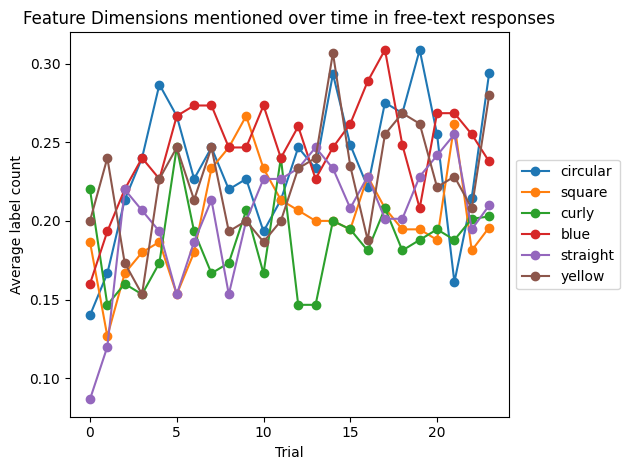

In [33]:
def count_labels_over_time(free_text_list, word_labels):
    """
    free_text_list: list of free-text responses (strings) in order
    word_labels: dict mapping label -> list of words
    Returns a list of dicts (one per trial) with counts per label
    """
    counts_over_time = []

    for text in free_text_list:
        text_lower = text.lower()  # lowercase 
        counts = {label: 0 for label in word_labels}

        for label, words in word_labels.items():
            for word in words:
                counts[label] += text_lower.count(word)  # count occurrences
        counts_over_time.append(counts)

    return counts_over_time


word_labels = {
    'circular': ['circle', 'circular', 'oval', 'round'],
    'square': ['square', 'squared', 'rectangle', 'rectangular'],
    'curly': ['curly'],
    'straight': ['straight'],
    'blue': ['blue'],
    'yellow': ['yellow']
}

all_counts = []

for idx, row in df_accommodate.iterrows():
    participant_id = row['participant'] 
    free_text_list = row['free_texts']
    
    counts = count_labels_over_time(free_text_list, word_labels)
    
    # Add participant ID and timepoint
    for trial, count_dict in enumerate(counts):
        count_dict.update({'participant': participant_id, 'trial': trial})
        all_counts.append(count_dict)

# Convert to DataFrame for analysis
df_counts = pd.DataFrame(all_counts)
df_grouped = df_counts.groupby('trial')[['circular','square','curly', 'blue', 'straight', 'yellow']].mean()
df_grouped.plot(marker='o')
plt.xlabel('Trial')
plt.ylabel('Average label count')
plt.title('Feature Dimensions mentioned over time in free-text responses')
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.tight_layout() 
plt.show()
plt.show()


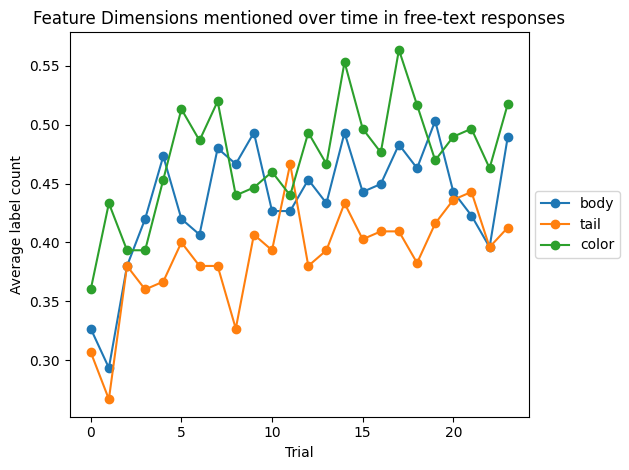

In [35]:
word_labels = {
    'body': ['circle', 'circular', 'oval', 'round', 'square', 'squared', 'rectangle', 'rectangular'],
    'tail': ['curly', 'straight'],
    'color': ['blue', 'yellow']
}

all_counts = []

for idx, row in df_accommodate.iterrows():
    participant_id = row['participant'] 
    free_text_list = row['free_texts']
    
    counts = count_labels_over_time(free_text_list, word_labels)
    
    # Add participant ID and timepoint
    for trial, count_dict in enumerate(counts):
        count_dict.update({'participant': participant_id, 'trial': trial})
        all_counts.append(count_dict)

# Convert to DataFrame for analysis
df_counts = pd.DataFrame(all_counts)
df_grouped = df_counts.groupby('trial')[['body', 'tail', 'color']].mean()
df_grouped.plot(marker='o')
plt.xlabel('Trial')
plt.ylabel('Average label count')
plt.title('Feature Dimensions mentioned over time in free-text responses')
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.tight_layout() 
plt.show()
plt.show()

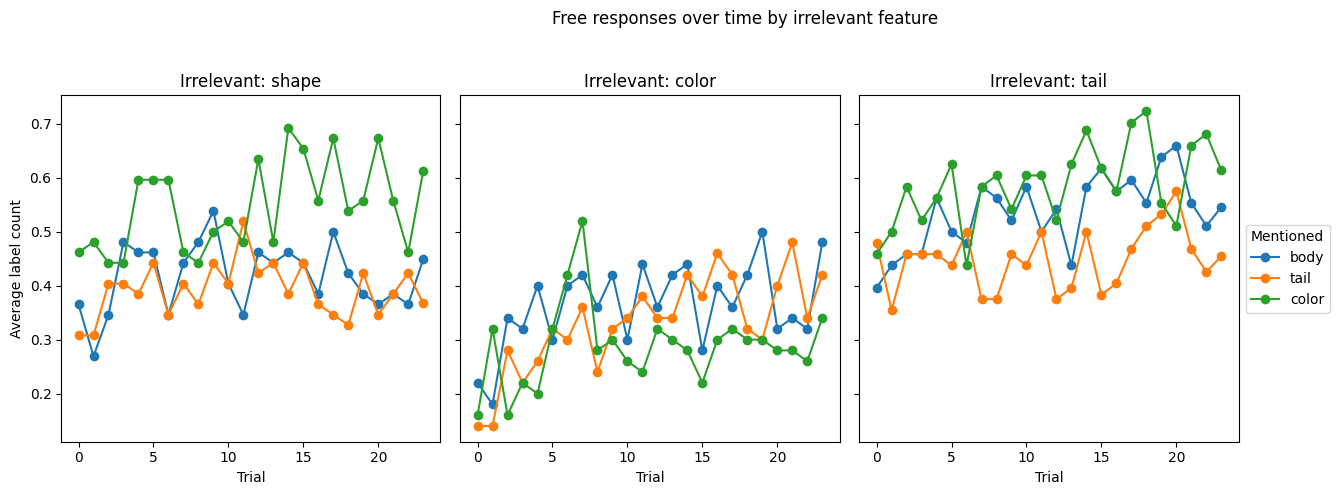

In [ ]:
def analyze_free_text_labels(df, word_labels, task_name='accommodate'):
    """
    df: DataFrame with columns ['participant', 'free_texts', 'irrelevant_dim']
    word_labels: dict mapping label -> list of words
    task_name: just for plot titles
    """
    all_counts = []

    for idx, row in df.iterrows():
        participant_id = row['participant']
        free_text_list = row['free_texts']
        irrelevant_feature = row['irrelevant_dim']

        counts = count_labels_over_time(free_text_list, word_labels)
        
        # Add participant ID, trial, and irrelevant_dim
        for trial, count_dict in enumerate(counts):
            count_dict.update({
                'participant': participant_id,
                'trial': trial,
                'irrelevant_dim': irrelevant_feature
            })
            all_counts.append(count_dict)

    # Convert to DataFrame
    df_counts = pd.DataFrame(all_counts)

    # Plot per irrelevant feature
    labels = list(word_labels.keys())
    irr_feats = df_counts['irrelevant_dim'].unique()
    fig, axes = plt.subplots(1, len(irr_feats), figsize=(15,5), sharey=True)

    for ax, irr_feat in zip(axes, irr_feats):
        df_grouped = df_counts[df_counts['irrelevant_dim'] == irr_feat] \
                        .groupby('trial')[labels].mean()
        df_grouped.plot(ax=ax, marker='o', legend=False)
        ax.set_title(f'Irrelevant: {irr_feat}')
        ax.set_xlabel('Trial')
        ax.set_ylabel('Average label count')

    plt.suptitle('Free responses over time by irrelevant feature')
    plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), title='Mentioned')
    plt.tight_layout(rect=[0, 0, 0.9, 0.95])  # leave space for suptitle
    plt.show()

    return df_counts
df_counts = analyze_free_text_labels(df_accommodate, word_labels)


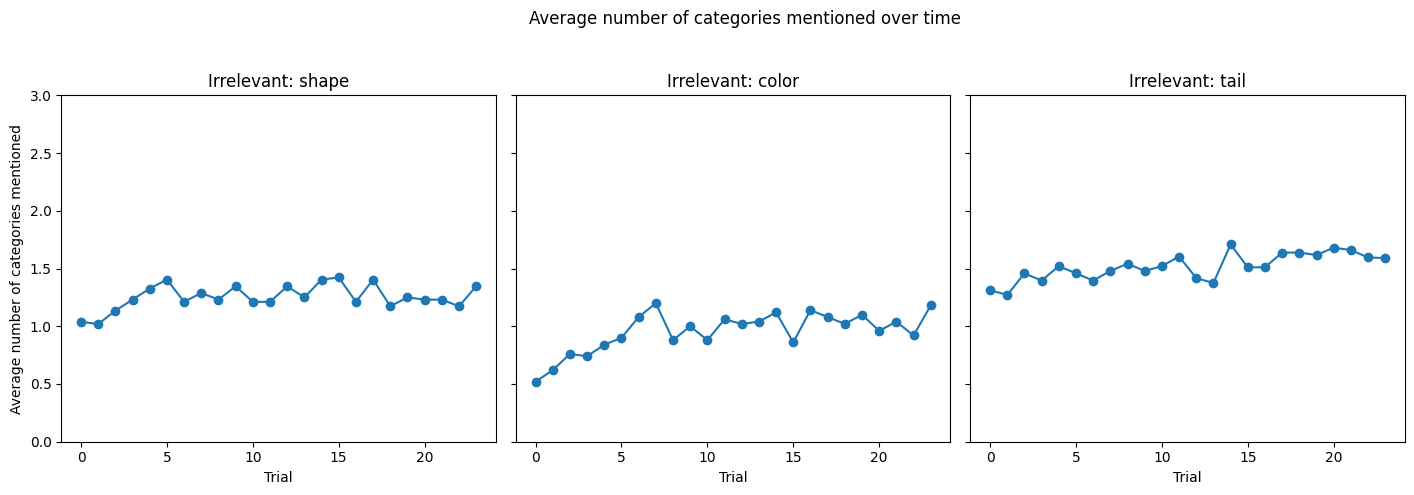

In [36]:
def analyze_free_text_num_mentions(df, word_labels, task_name='accommodate'):
    """
    df: DataFrame with columns ['participant', 'free_texts', 'irrelevant_dim']
    word_labels: dict mapping label -> list of words
    Returns: df_counts with number of categories mentioned per trial and plots 0-3 mentions over time
    """
    all_counts = []

    for idx, row in df.iterrows():
        participant_id = row['participant']
        free_text_list = row['free_texts']
        irrelevant_feature = row['irrelevant_dim']

        counts = count_labels_over_time(free_text_list, word_labels)
        
        # Convert counts into number of categories mentioned (0-3)
        for trial, count_dict in enumerate(counts):
            num_mentions = sum([1 for lbl in word_labels if count_dict[lbl] > 0])
            all_counts.append({
                'participant': participant_id,
                'trial': trial,
                'irrelevant_dim': irrelevant_feature,
                'num_mentions': num_mentions
            })

    df_counts = pd.DataFrame(all_counts)

    # Plot per irrelevant feature (0-3 mentions)
    irr_feats = df_counts['irrelevant_dim'].unique()
    fig, axes = plt.subplots(1, len(irr_feats), figsize=(15,5), sharey=True)

    for ax, irr_feat in zip(axes, irr_feats):
        df_grouped = df_counts[df_counts['irrelevant_dim'] == irr_feat] \
                        .groupby('trial')['num_mentions'].mean()
        df_grouped.plot(ax=ax, marker='o', linestyle='-')
        ax.set_title(f'Irrelevant: {irr_feat}')
        ax.set_xlabel('Trial')
        ax.set_ylabel('Average number of categories mentioned')
        ax.set_ylim(0, 3)  # 0-3 mentions possible

    plt.suptitle('Average number of categories mentioned over time')
    plt.tight_layout(rect=[0, 0, 0.95, 0.95])
    plt.show()

    return df_counts
df_counts = analyze_free_text_num_mentions(df_accommodate, word_labels)

In [ ]:
#Group by average food amount per item in training
df = df_combined[['task', 'training_image_order', 'food_amount', 'conditionOrder', 'color_high', 'tail_high', 'shape_high', 'irrelevant_dim', 
                  'tail_importance', 'color_importance', 'shape_importance']]
df_long3 = (
    df
    .explode(['training_image_order', 'food_amount'])
    .rename(columns={'training_image_order': 'item'})
)
avg_food_extended = (
    df_long3
    .groupby(['task', 'conditionOrder', 'item'], as_index=False)
    .agg(
        food_amount=('food_amount', 'mean'),
        color_high=('color_high', 'first'),
        tail_high=('tail_high', 'first'),
        shape_high=('shape_high', 'first'),
        irrelevant_dim=('irrelevant_dim', 'first')
    )
)

avg_food_train_extended = avg_food_extended.copy()

df = avg_food_train_extended.copy()

#print(df)
df['high_or_low'] = df.apply(
    lambda row: 'high' if row[f"{row['irrelevant_dim']}_high"] == row[f"{row['irrelevant_dim']}_high"] else 'low',
    axis=1
)
def get_irrelevant_value(row):
    tail, color, shape = row['item'].split('_')
    if row['irrelevant_dim'] == 'tail':
        return tail
    elif row['irrelevant_dim'] == 'color':
        return color
    elif row['irrelevant_dim'] == 'shape':
        return shape
    else:
        return None

df['irrelevant_value'] = df.apply(get_irrelevant_value, axis=1)

# Quick check
#print(df[['item', 'irrelevant_dim', 'irrelevant_value', 'tail_high', 'color_high', 'shape_high']].head(20))
df['high_or_low'] = df.apply(
    lambda row: 'high' if row['irrelevant_value'] == row[f"{row['irrelevant_dim']}_high"] else 'low',
    axis=1
)

# Debug
#print(df[['item', 'irrelevant_dim', 'irrelevant_value', 'high_or_low']].head(20))
# Compute high vs low difference
high_low_diff = (
    df.groupby(['task', 'conditionOrder', 'irrelevant_dim', 'high_or_low'])['food_amount']
      .mean()             # average food amount per high/low
      .unstack(fill_value=0)  # columns become 'high' and 'low'; missing = 0
)

# Compute high_minus_low
high_low_diff['high_minus_low'] = high_low_diff['high'] - high_low_diff['low']

# Reset index for a clean table
high_low_diff = high_low_diff.reset_index()

print(high_low_diff[['task', 'conditionOrder', 'irrelevant_dim', 'high_minus_low']])



In [ ]:
import pandas as pd

# Get Relevant Columns
df = df_combined[['task', 'training_image_order', 'food_amount', 'conditionOrder',
                  'color_high', 'tail_high', 'shape_high', 'irrelevant_dim',
                  'tail_importance', 'color_importance', 'shape_importance']]

# Explode lists into rows
df_long = df.explode(['training_image_order', 'food_amount']).rename(columns={'training_image_order': 'item'})

# 3️Compute mean food amount per item
df_items = (
    df_long.groupby(['task', 'conditionOrder', 'item'], as_index=False)
           .agg(
               food_amount=('food_amount', 'mean'),
               color_high=('color_high', 'first'),
               tail_high=('tail_high', 'first'),
               shape_high=('shape_high', 'first'),
               irrelevant_dim=('irrelevant_dim', 'first'),
               tail_importance=('tail_importance', 'first'),
               color_importance=('color_importance', 'first'),
               shape_importance=('shape_importance', 'first')
           )
)

# Extract actual value of the irrelevant dimension from the item
def get_irrelevant_value(row):
    tail, color, shape = row['item'].split('_')
    if row['irrelevant_dim'] == 'tail':
        return tail
    elif row['irrelevant_dim'] == 'color':
        return color
    elif row['irrelevant_dim'] == 'shape':
        return shape

df_items['irrelevant_value'] = df_items.apply(get_irrelevant_value, axis=1)

# Determine if each item is high or low along the irrelevant dimension
df_items['high_or_low'] = df_items.apply(
    lambda row: 'high' if row['irrelevant_value'] == row[f"{row['irrelevant_dim']}_high"] else 'low',
    axis=1
)

# Get importance for irrelevant feature for each item
df_items['irrelevant_importance'] = df_items.apply(
    lambda row: row[f"{row['irrelevant_dim']}_importance"], axis=1
)

# Compute high vs low differences and keep importance score
agg = (
    df_items.groupby(['task', 'conditionOrder', 'irrelevant_dim', 'high_or_low'])
            .agg(
                food_amount_mean=('food_amount', 'mean'),
                irrelevant_importance_mean=('irrelevant_importance', 'mean')
            )
            .unstack(fill_value=0)  # separate 'high' and 'low'
)

# Compute high_minus_low
agg['high_minus_low'] = agg['food_amount_mean']['high'] - agg['food_amount_mean']['low']

# Get irrelevant importance
agg['irrelevant_importance'] = agg['irrelevant_importance_mean']['high']

# Reset index and select final columns
final_df = agg.reset_index()[['task', 'conditionOrder', 'irrelevant_dim', 'high_minus_low', 'irrelevant_importance']]
final_df['high_minus_low'] = pd.to_numeric(final_df['high_minus_low'], errors='coerce')
final_df['irrelevant_importance'] = pd.to_numeric(final_df['irrelevant_importance'], errors='coerce')

print(final_df.head(10))


In [ ]:
# Position-based decoding
FEATURE_INDEX = {
    "tail":  0,  # T or N
    "color": 1,  # B or Y
    "shape": 2   # S or C
}
def extract_feature(stimulus, feature):
    """
    stimulus: string like 'T_B_S'
    feature: 'tail', 'color', or 'shape'
    """
    return stimulus.split("_")[FEATURE_INDEX[feature]]
mapping = {
    "tail":  {"T": 1, "N": 0},
    "shape": {"S": 1, "C": 0},
    "color": {"B": 1, "Y": 0}
}
cols_to_keep = [
    "participant",
    "task",
    "conditionOrder",
    "irrelevant_dim",
    "food_amount",
    "training_color",
    "training_shape",
    "training_tail",
    "training_image_order",
    "tail_importance",
    "shape_importance",
    "color_importance"
]

def compute_true_irrelevant_assoc(row):
    irrel_feat = row["irrelevant_dim"]

    # Food values
    food = np.array(
        ast.literal_eval(row["food_amount"])
        if isinstance(row["food_amount"], str)
        else row["food_amount"],
        dtype=float
    )

    # Extract irrelevant feature value per training trial
    irrel_vals = np.array([
        mapping[irrel_feat][
            extract_feature(stim, irrel_feat)
        ]
        for stim in row["training_image_order"]
    ])

    mean_high = food[irrel_vals == 1].mean()
    mean_low  = food[irrel_vals == 0].mean()

    return mean_high - mean_low
df_irrel_truth = df_combined[cols_to_keep].copy()

df_irrel_truth["true_irrelevant_assoc"] = df_irrel_truth.apply(
    compute_true_irrelevant_assoc,
    axis=1
)

df_irrel_truth[
    ["task", "conditionOrder", "irrelevant_dim", "true_irrelevant_assoc", "color_importance", "shape_importance", "tail_importance"]
]

In [ ]:
def get_irrelevant_importance(row):
    return row[f"{row['irrelevant_dim']}_importance"]

df_plot = df_irrel_truth.copy()
df_plot["irrelevant_importance"] = df_plot.apply(
    get_irrelevant_importance, axis=1
)

plt.figure(figsize=(9, 4))

sns.scatterplot(
    data=df_plot,
    x="true_irrelevant_assoc",
    y="irrelevant_importance",
    hue="task",
    style="task",
    s=60
)

for task, sub in df_plot.groupby("task"):
    sns.regplot(
        data=sub,
        x="true_irrelevant_assoc",
        y="irrelevant_importance",
        scatter=False,
        ci=None,
        label=f"{task} fit"
    )

plt.axhline(0, color="gray", linestyle="--")
plt.axvline(0, color="gray", linestyle="--")

plt.xlabel("True irrelevant association")
plt.ylabel("Irrelevant dimension rating")
plt.title("Irrelevant Dimension Rating vs True Association")
plt.legend(
    title="Task",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()


